# Programming Assignment 1

Segmentação de instâncias com as arquiteturas da aula

Equipe: Jaime Willian Carneiro da Silva & Luiz Eduardo Bravin

## Datasets 

Escolheremos a opção A - DSB2018 / BBBC038v1

Download:  https://bbbc.broadinstitute.org/BBBC038

## Modelo

- falar sobre o modelo escolhido: Unet Binaria e D dimensional

## Métricas

- mostrar como as metricas estao sendo calculadas

A regra de matching utilizada foi a guloso por IoU.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..')) 
%load_ext autoreload
%autoreload 2
from src import *
import torch
import numpy as np
from pathlib import Path
from torch.utils.data import DataLoader, random_split
import time

In [2]:
def main(model_type, part, batch_size=16, epochs=10, lr=1e-4):
    # Reprodutividade
    torch.manual_seed(42)
    np.random.seed(42)

    # Modelo
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'xpu' if hasattr(torch, 'xpu') and torch.xpu.is_available() else 'cpu')
    # MODEL = UNetBinary() if part == 1 else UNetDDimensional()
    MODEL = UNetBinary() if part == 1 else UNetTernary()
    MODEL = MODEL.to(DEVICE)

    # Dataset
    if model_type == 'synthetic':
        train_dataset = SyntheticEllipseDataset(num_samples=536, img_size=128, part=part)
        val_dataset = SyntheticEllipseDataset(num_samples=134, img_size=128, part=part)
        test_dataset = SyntheticEllipseDataset(num_samples=65, img_size=128, part=part)

    elif model_type == 'real':
        PATH_TRAIN = Path('../data/stage1_train')
        PATH_TEST = Path('../data/stage1_test')
        full_dataset = DSB2018Dataset(root_dir=PATH_TRAIN, img_size=128,  part=part, cache_in_memory=True)
        train_size = int(0.8 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
        test_dataset = DSB2018Dataset(root_dir=PATH_TEST, img_size=128,  part=part, cache_in_memory=True)

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

    # Treinamento
    start = time.time()
    history = training(
                model=MODEL,
                dataloader=train_loader,
                device=DEVICE,
                part=part,
                lr=lr,
                num_epochs=epochs,
    )
    print(f'Tempo de treinamento: {(time.time() - start)/60:.2f} minutos')

    # Avaliação
    real_mAP, real_count_errors, real_densities, real_samples = evaluate(MODEL, val_loader, DEVICE, part=part)

    # Plotando métricas e amostras
    plot_metrics(real_mAP, real_count_errors, real_densities)
    plot_samples(real_samples, part=part)
        

## Parte 0

Treinando em: xpu
Batches por época: 34
Epoch 1/10 | Loss: 0.6312 | IoU: 0.6342 | Dice: 0.7761
Epoch 2/10 | Loss: 0.3395 | IoU: 0.7894 | Dice: 0.8823
Epoch 3/10 | Loss: 0.1141 | IoU: 0.9529 | Dice: 0.9759
Epoch 4/10 | Loss: 0.0508 | IoU: 0.9676 | Dice: 0.9835
Epoch 5/10 | Loss: 0.0401 | IoU: 0.9747 | Dice: 0.9872
Epoch 6/10 | Loss: 0.0524 | IoU: 0.9660 | Dice: 0.9827
Epoch 7/10 | Loss: 0.0383 | IoU: 0.9766 | Dice: 0.9882
Epoch 8/10 | Loss: 0.0312 | IoU: 0.9808 | Dice: 0.9903
Epoch 9/10 | Loss: 0.0302 | IoU: 0.9811 | Dice: 0.9905
Epoch 10/10 | Loss: 0.0268 | IoU: 0.9833 | Dice: 0.9916
Tempo de treinamento: 1.10 minutos
Média global mAP: 0.0929
Média global Erro Absoluto de Contagem: 10.1642


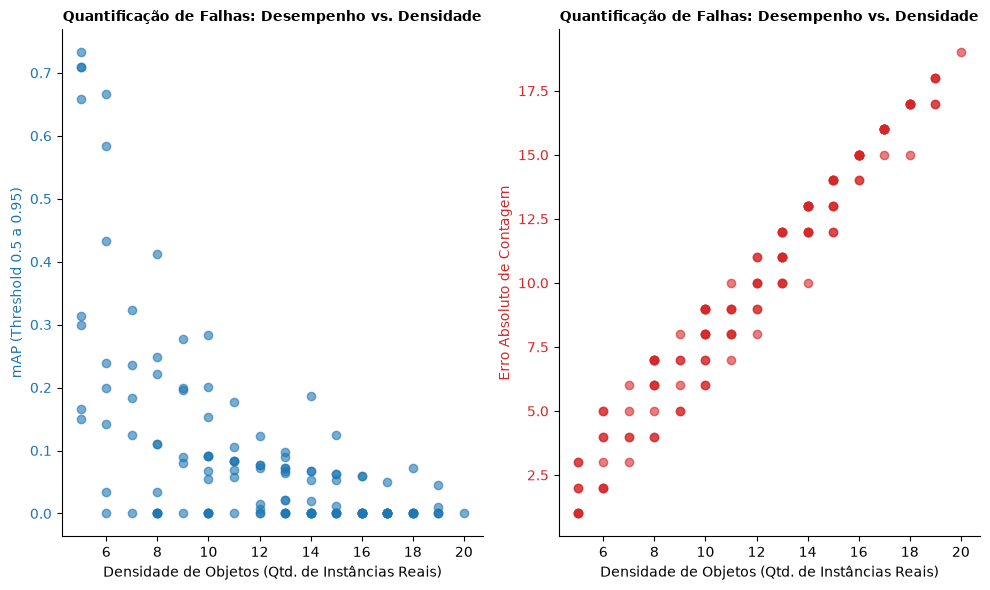

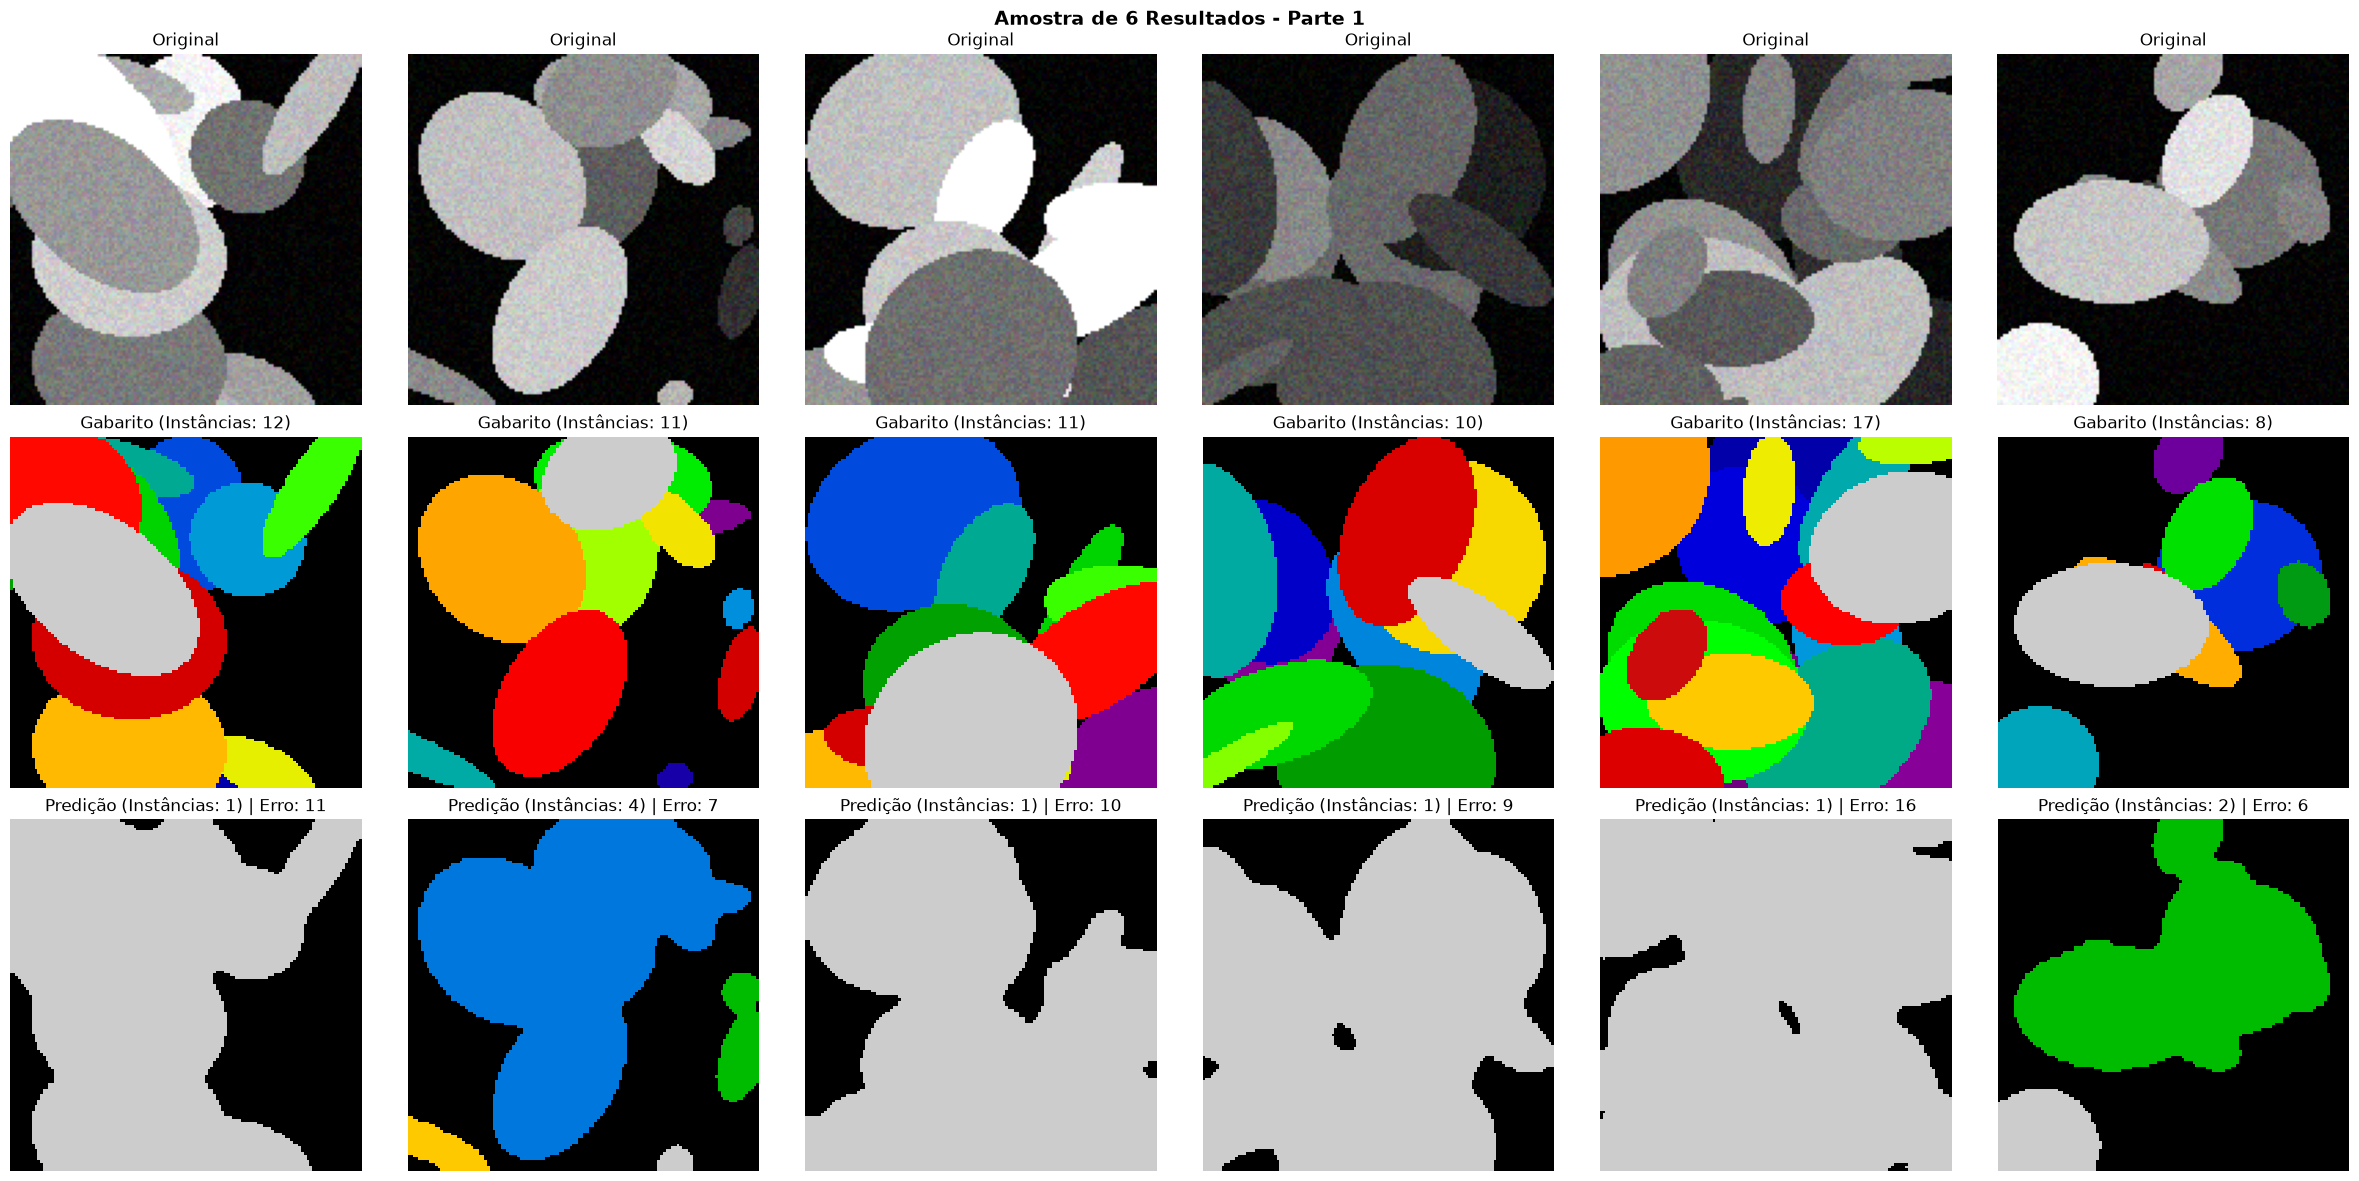

In [3]:
main(model_type='synthetic', part=1)

Quanto maior a quantidade de elipses, maior facilidade de ter intersecção entre elas. Com isso, o modelo interpreta como se fosse apenas um objeto, logo diminuindo o mAP e aumentando o erro absoluto de contagem. 

## Parte 01

Treinando em: xpu
Batches por época: 34
Epoch 1/10 | Loss: 0.6759 | IoU: 0.1269 | Dice: 0.2253
Epoch 2/10 | Loss: 0.3595 | IoU: 0.0000 | Dice: 0.0000
Epoch 3/10 | Loss: 0.2830 | IoU: 0.0000 | Dice: 0.0000
Epoch 4/10 | Loss: 0.2258 | IoU: 0.1099 | Dice: 0.1980
Epoch 5/10 | Loss: 0.1805 | IoU: 0.5150 | Dice: 0.6799
Epoch 6/10 | Loss: 0.1495 | IoU: 0.6240 | Dice: 0.7685
Epoch 7/10 | Loss: 0.1258 | IoU: 0.6721 | Dice: 0.8039
Epoch 8/10 | Loss: 0.1159 | IoU: 0.6940 | Dice: 0.8193
Epoch 9/10 | Loss: 0.1091 | IoU: 0.7108 | Dice: 0.8309
Epoch 10/10 | Loss: 0.1049 | IoU: 0.7227 | Dice: 0.8390
Tempo de treinamento: 1.36 minutos
Média global mAP: 0.2391
Média global Erro Absoluto de Contagem: 25.4328


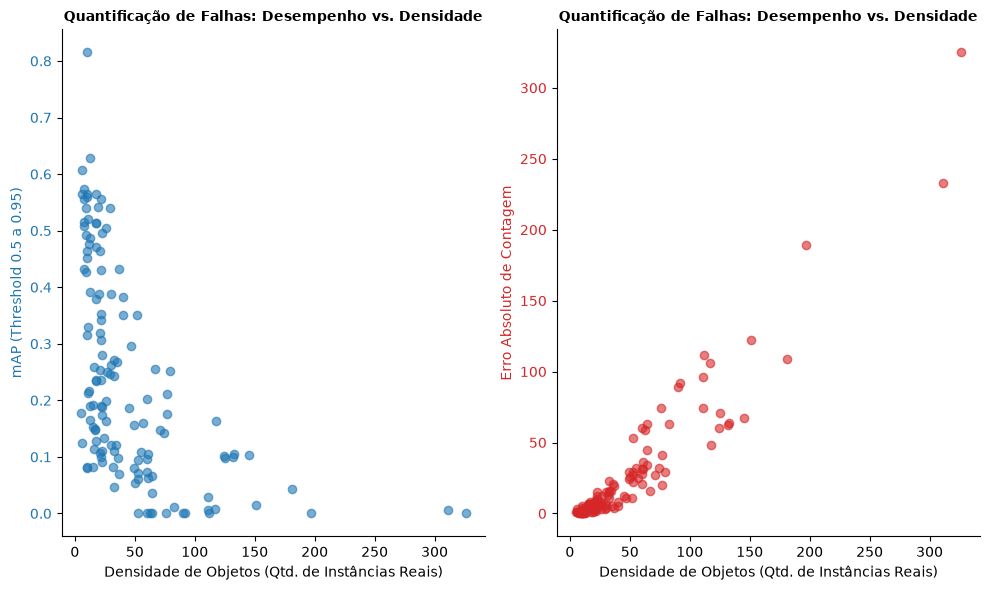

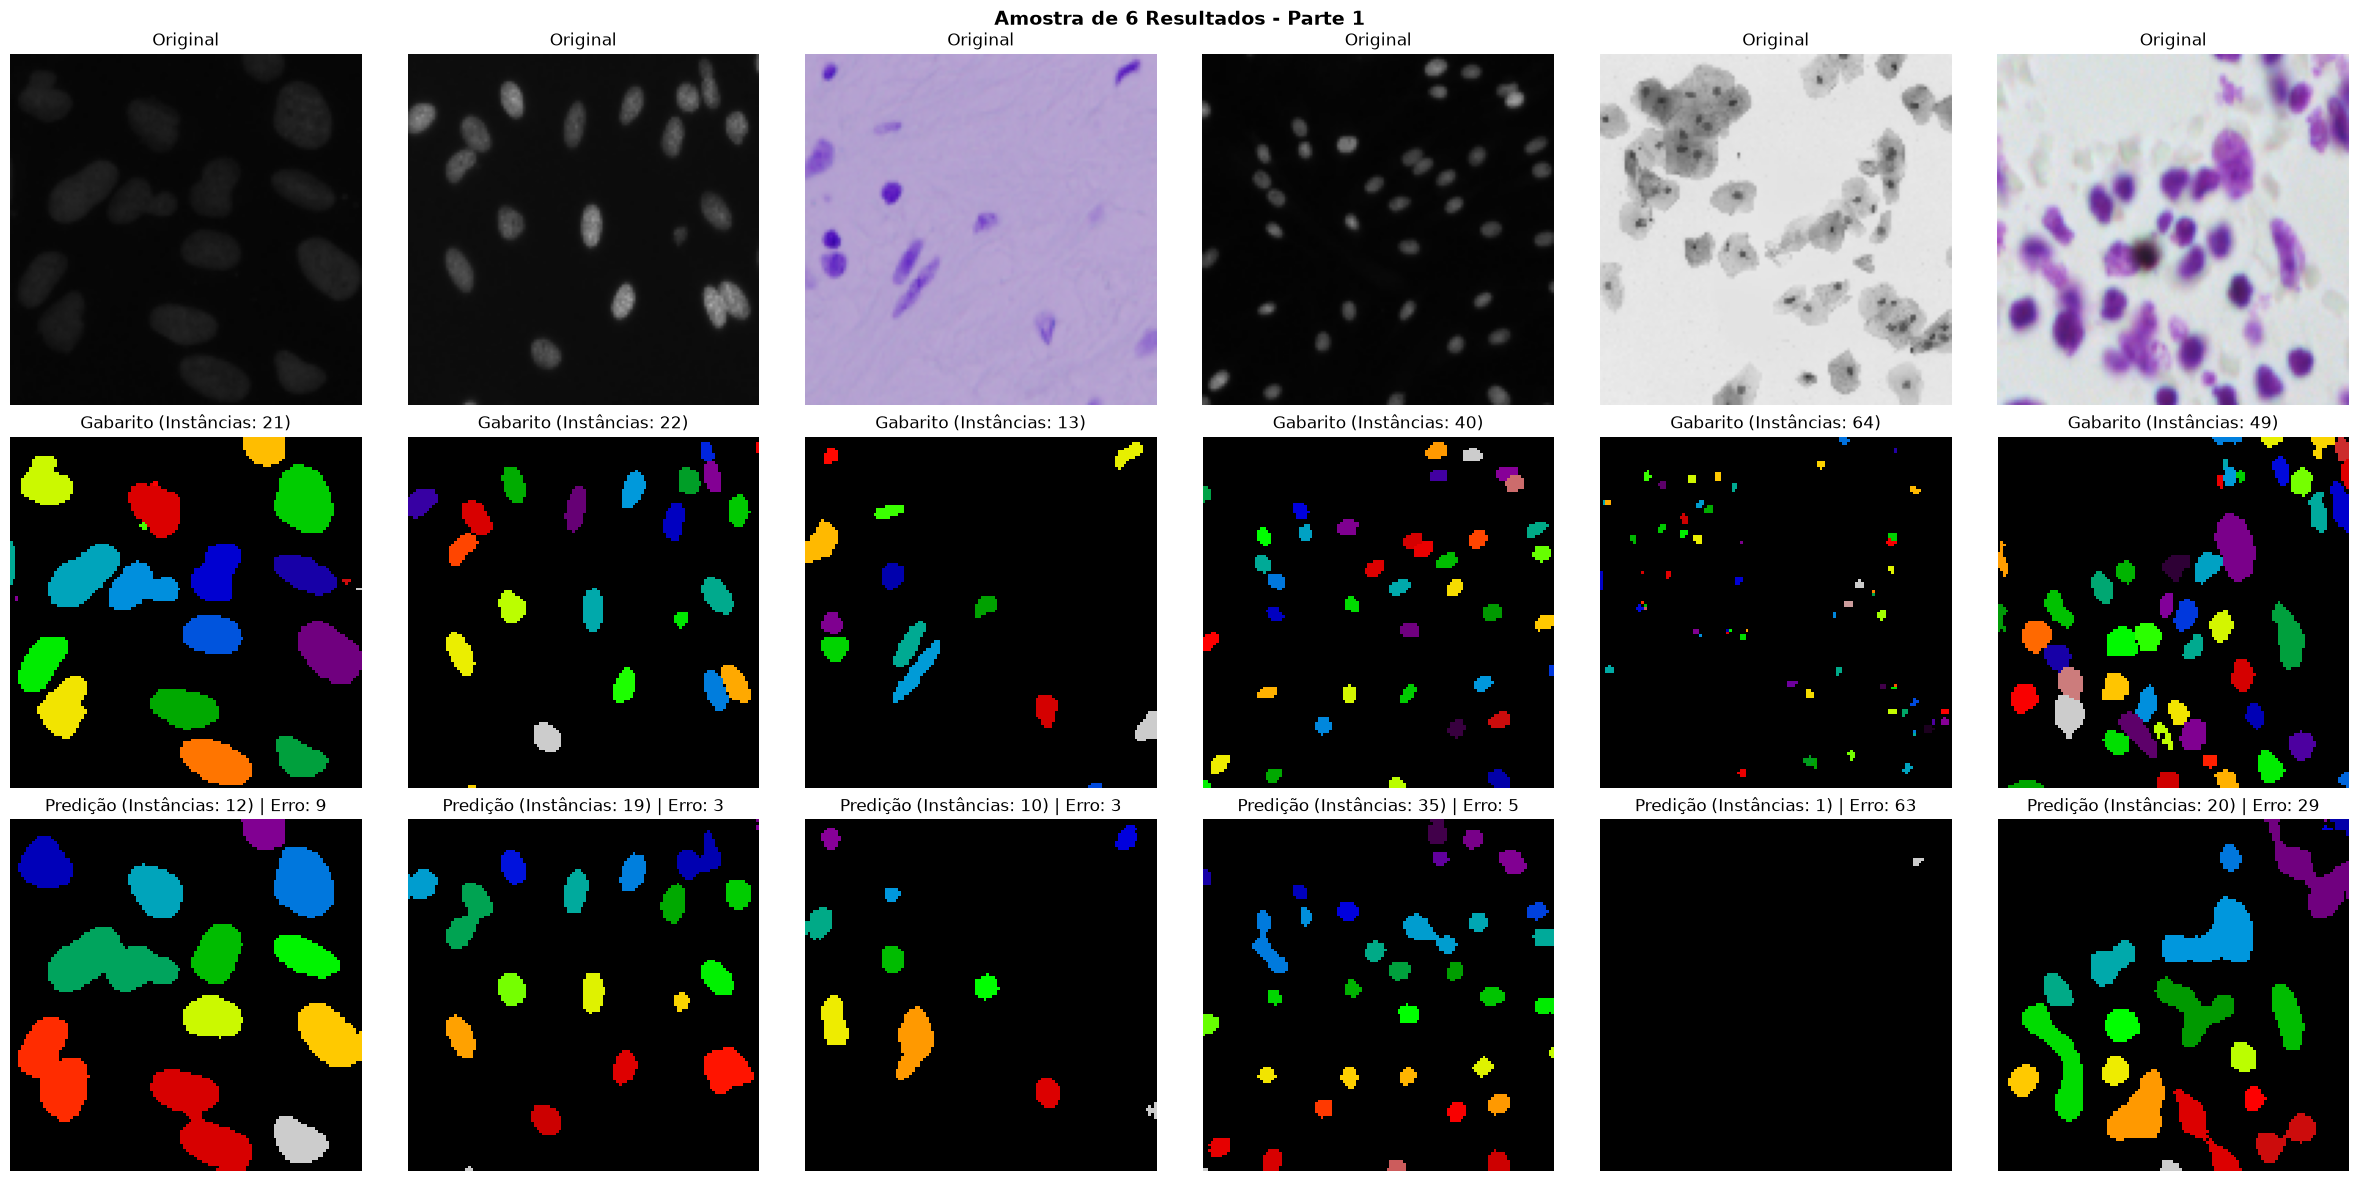

In [4]:
main(model_type='real', part=1)

## Parte 02

Parte 2 - Trilha B

Treinando em: xpu
Batches por época: 34
Epoch 1/10 | Loss: 1.0034 | IoU: 0.0000 | Dice: 0.0000
Epoch 2/10 | Loss: 0.7745 | IoU: 0.0000 | Dice: 0.0000
Epoch 3/10 | Loss: 0.5872 | IoU: 0.0000 | Dice: 0.0000
Epoch 4/10 | Loss: 0.4523 | IoU: 0.0000 | Dice: 0.0000
Epoch 5/10 | Loss: 0.3737 | IoU: 0.3191 | Dice: 0.4838
Epoch 6/10 | Loss: 0.3313 | IoU: 0.5223 | Dice: 0.6862
Epoch 7/10 | Loss: 0.3292 | IoU: 0.4997 | Dice: 0.6664
Epoch 8/10 | Loss: 0.2948 | IoU: 0.5583 | Dice: 0.7165
Epoch 9/10 | Loss: 0.2834 | IoU: 0.5758 | Dice: 0.7308
Epoch 10/10 | Loss: 0.2734 | IoU: 0.5894 | Dice: 0.7417
Tempo de treinamento: 1.38 minutos
Média global mAP: 0.1470
Média global Erro Absoluto de Contagem: 38.2164


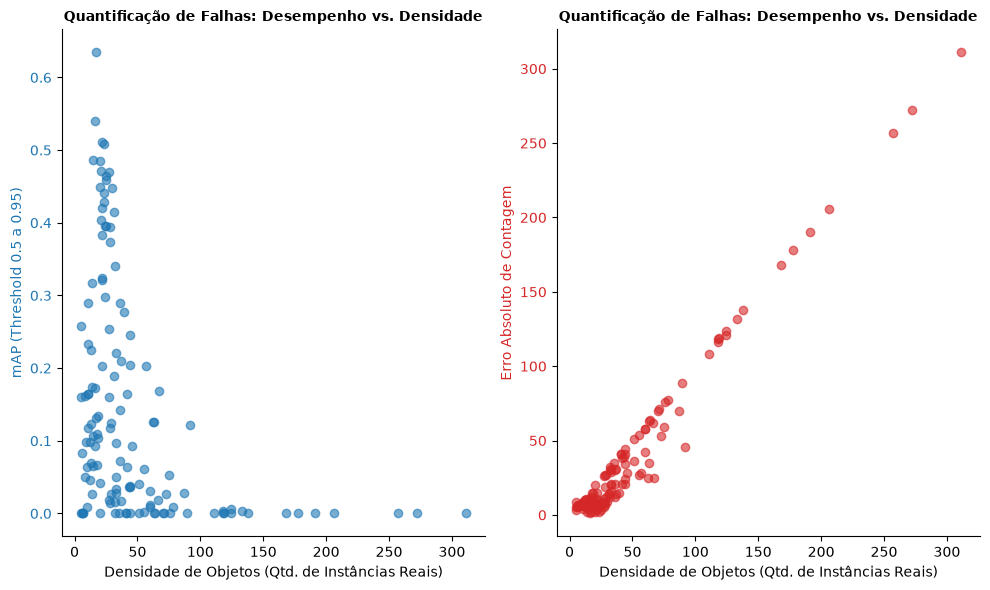

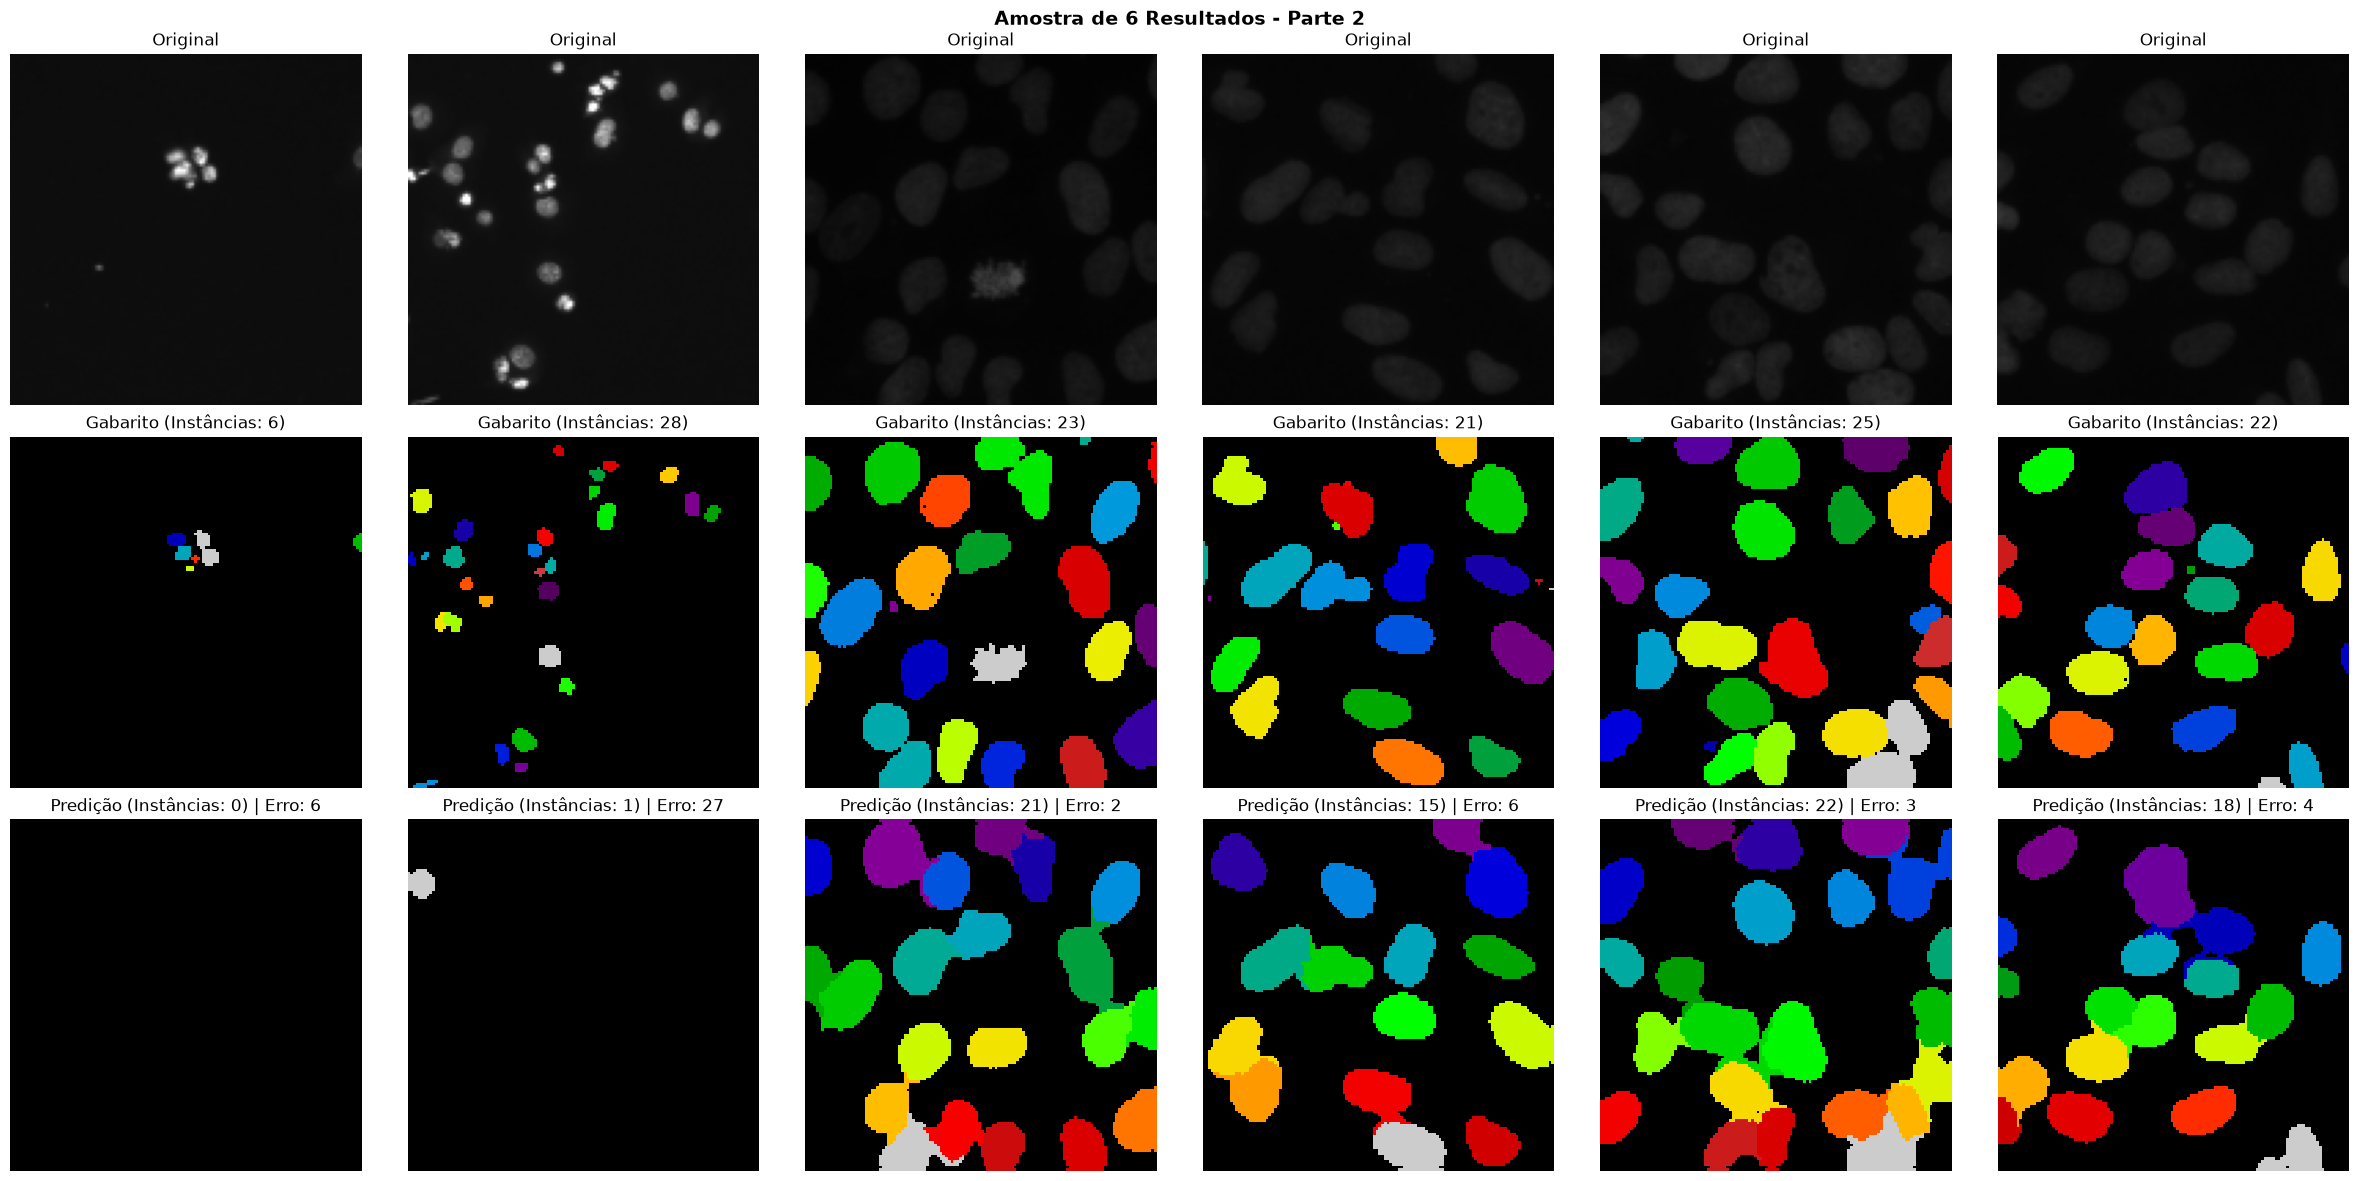

In [5]:
main(model_type='real', part=2)

## Parte 03

Eixos 1 e 3

## Parte 04

## Parte 05

## Parte 06